Question T1


On a $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ avec $X_0$ et $X_1$ indépendants, $\mu_0$ admet une densité $f_0$ et $\mu_1$ admet une densité $f_1$.

On a :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } g \text{ est une fonction continue et } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(x_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f(x_0) \, f(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi



Text(0.5, 1.0, 'cas 1 avec loi uniforme et loi normale')

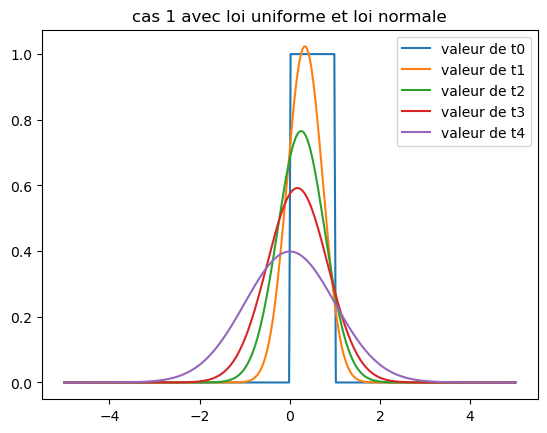

In [27]:
#on pose le x et le t test1 pour représenter la fonction
#
Lx=np.linspace(-5,5,300)
Lt=[0,1/3,1/2,2/3,1]

def fcas1(x0):
    return sps.uniform.pdf(x0, loc=0, scale=1)*sps.norm.pdf((x-(1-t)*x0)/t, loc=0, scale=1)
Ftcas1=[]
plt.plot(Lx, sps.uniform.pdf(Lx, loc=0, scale=1),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas1,0,1)
        Ft.append((1/t)*integrale[0])
    Ftcas1.append(Ft)
    plt.plot(Lx, Ftcas1[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 1 avec loi uniforme et loi normale")

Text(0.5, 1.0, 'cas 2 avec deux lois uniformes')

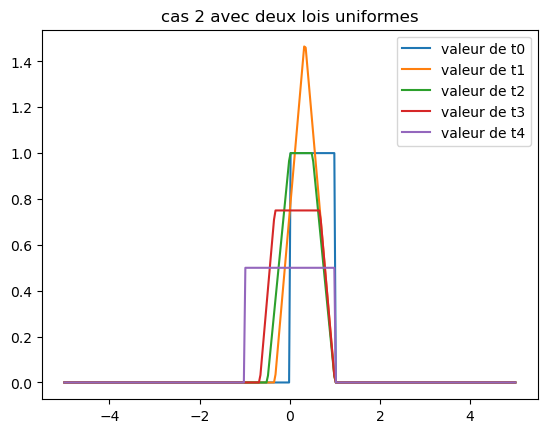

In [29]:

def fcas2(x0):
    return sps.uniform.pdf(x0, loc=0, scale=1)*sps.uniform.pdf((x-(1-t)*x0)/t, loc=-1, scale=2)
Ftcas2=[]
plt.plot(Lx, sps.uniform.pdf(Lx, loc=0, scale=1),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas2,0,1)
        Ft.append((1/t)*integrale[0])
    Ftcas2.append(Ft)
    plt.plot(Lx, Ftcas2[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 2 avec deux lois uniformes")

Text(0.5, 1.0, 'cas 2 avec deux lois normales')

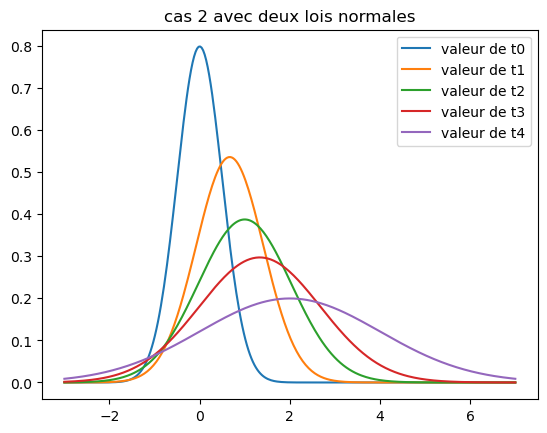

In [34]:
Lx=np.linspace(-3,7,300)
def fcas3(x0):
    return sps.norm.pdf(x0, loc=0, scale=0.5)*sps.norm.pdf((x-(1-t)*x0)/t, loc=2, scale=2)
Ftcas3=[]
plt.plot(Lx, sps.norm.pdf(Lx, loc=0, scale=0.5),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas3,-np.inf, np.inf)
        Ft.append((1/t)*integrale[0])
    Ftcas3.append(Ft)
    plt.plot(Lx, Ftcas3[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 2 avec deux lois normales")